In [26]:
#Import libraries and desfine project paths
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#Define path to the raw vehicle price dataset
DATA_PATH=Path("../data/raw/car_price_dataset.csv")

#Define directories for saving generated figures and analysis tables
FIG_DIR=Path("../reports/figures")
TABLE_DIR=Path("../reports/tables")

#Create the output directories 
FIG_DIR.mkdir(parents=True,exist_ok=True)
TABLE_DIR.mkdir(parents=True,exist_ok=True)

#Load vehicle price dataset into a pandas DataFrame
df=pd.read_csv(DATA_PATH)

#Convert listing date into a datetime format 
df["Date_parsed"]=pd.to_datetime(
    df["Date"],
    errors="coerce"
)

#Configure default seaborn visualization style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

#Allow pandas to display all columns when showing DataFrames
pd.set_option(
    "display.max_columns",
    None
)

In [27]:
#Price distribution

#Select non-missing vehicle prices for distribution analysis
price=df["Price"].dropna()

#Calculate mean vehicle price
print(
    f"Mean:{price.mean():.2f} lakhs"
)

#Identify minimum vehicle price
print(
    f"Minimum: {price.min():.2f} lakhs"
)

#Identify maximum vehcile price
print(
    f"Maximum: {price.max():2f} lakhs"
)

#Calculate the skewness of the price distribution
print(
    f"Skewness:{price.skew():.3f}"
)

Mean:53.41 lakhs
Minimum: 2.65 lakhs
Maximum: 790.000000 lakhs
Skewness:3.465


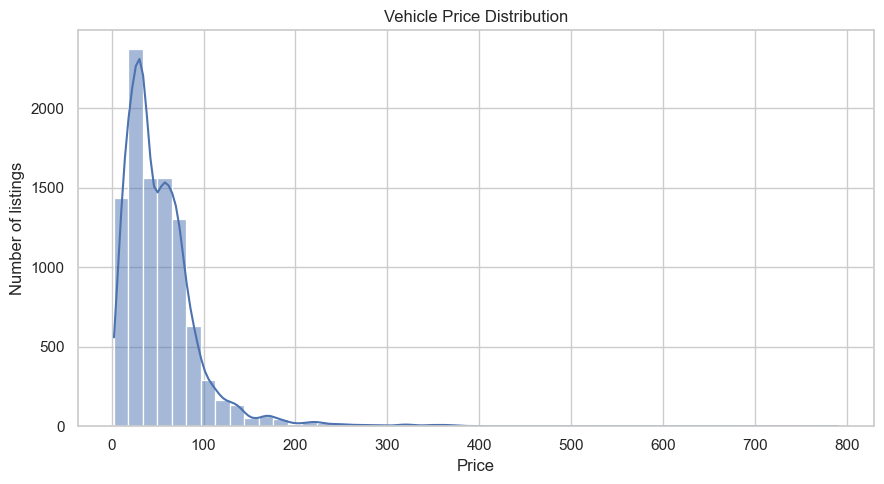

In [28]:
#Histogram

#Create a figure and axis for price distribution plot
fig, ax=plt.subplots(
    figsize=(9,5)
)

#Plot distribution of vehcile prices using a histogram and KDE curve
sns.histplot(
    price,
    bins=50,
    kde=True,
    ax=ax
)

ax.set_title(
    "Vehicle Price Distribution"
)

ax.set_ylabel(
    "Price(LKR lakhs)"
)

ax.set_ylabel(
    "Number of listings"
)

#Adjust layout to prevent overlapping elements
fig.tight_layout()

#Save price distribution figure
fig.savefig(
    FIG_DIR/"01_price_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

#Display plot
plt.show()

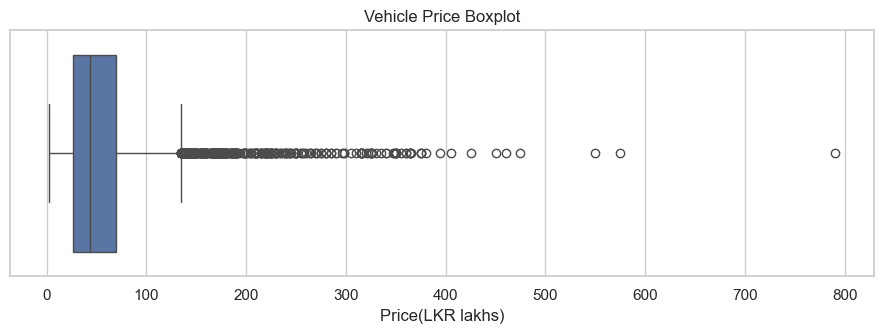

In [29]:
#Price Boxplot

#Create a boxplot to examine spread and potential outliers in vehicle prices
fig,ax=plt.subplots(
    figsize=(9,3.5)
)

#Plot vehicle price distribution as a horizontal boxplot
sns.boxplot(
    x=price,
    ax=ax
)

#Add a descriptive title to the boxplot
ax.set_title(
    "Vehicle Price Boxplot"
)

#Label the x-axis with the price unit
ax.set_xlabel(
    "Price(LKR lakhs)"
)

#Adjust layout
fig.tight_layout()

#Save boxplot as an image 
fig.savefig(
    FIG_DIR/"02_price_boxplot.png",
    dpi=200,
    bbox_inches="tight"
)

#Display plot 
plt.show()

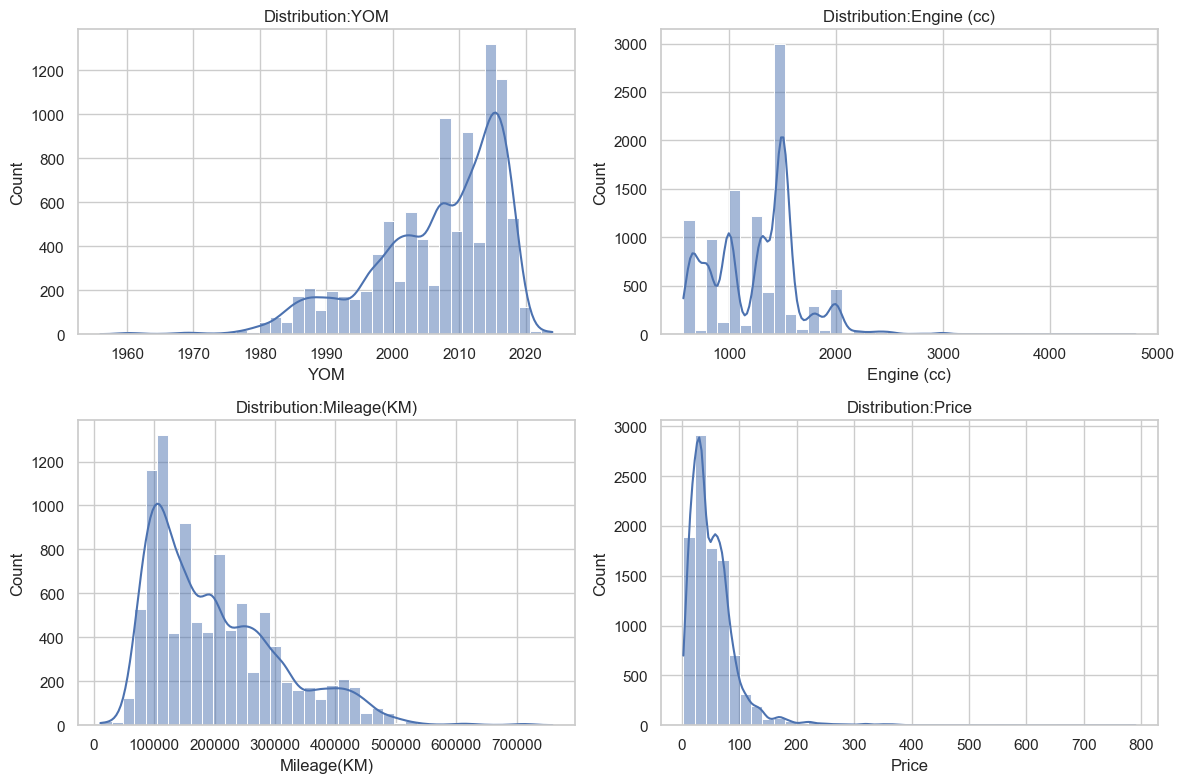

In [31]:
#Numeric Distributions

#Define numerical variables to be examined during EDA 
numeric_columns=[
    "YOM",
    "Engine (cc)",
    "Mileage(KM)",
    "Price"
]

##Create a 2*2 grid for the numerical distribution plots
fig,axes=plt.subplots(
    2,
    2,
    figsize=(12,8)
)

#Plot distribution of each numerical variable
for ax,column in zip(
    axes.ravel(),
    numeric_columns
):
    #Create histogram with a KDE curve for current variable
    sns.histplot(
        df[column].dropna(),
        bins=40,
        kde=True,
        ax=ax
    )
    #Add variable name as plot title 
    ax.set_title(
        f"Distribution:{column}"
    )

fig.tight_layout()

#Adjust the spacing between the plots
fig.savefig(
    FIG_DIR/"03_numeric_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

#Display plots
plt.show()

In [32]:
#Correlation Matrix

#Calculate Pearson correlations between selected numerical vairables 
correlation=df[
    numeric_columns 
].corr()

#Display correlation values rounded to 3 decimal places
display(
    correlation.round(3)
)

,YOM,Engine (cc),Mileage(KM),Price
YOM,1.000,-0.406,-1.000,0.506
Engine (cc),-0.406,1.000,0.406,0.193
Mileage(KM),-1.000,0.406,1.000,-0.506
Price,0.506,0.193,-0.506,1.000


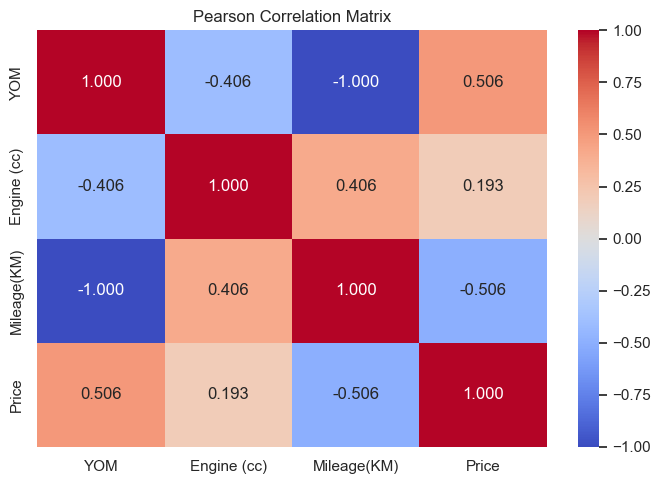

In [33]:
#Create a figure and axis for correlation heatmap
fig,ax=plt.subplots(
    figsize=(7,5)
)

#Vsualize the correlation matrix using a heatmap 
sns.heatmap(
    correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    ax=ax
)

#Add a descriptive title to the heatmap
ax.set_title(
    "Pearson Correlation Matrix"
)

#Adjust layout
fig.tight_layout()

#Save correlation heatmap
fig.savefig(
    FIG_DIR/"04_numeric_correlation_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

#Display the heatmap
plt.show()

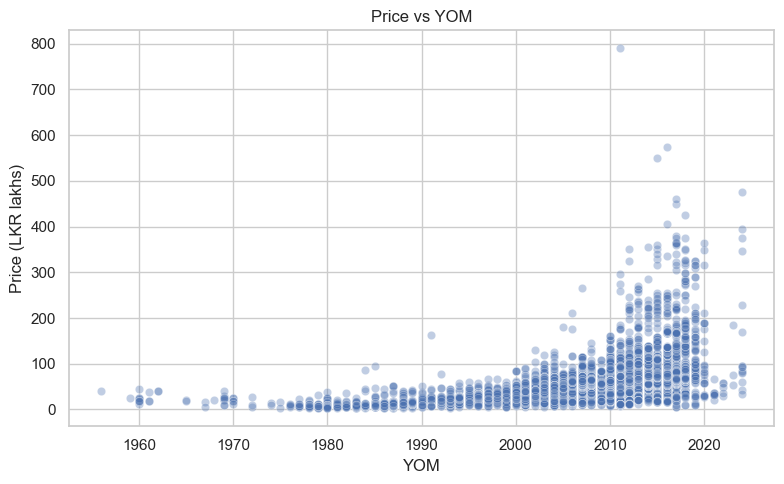

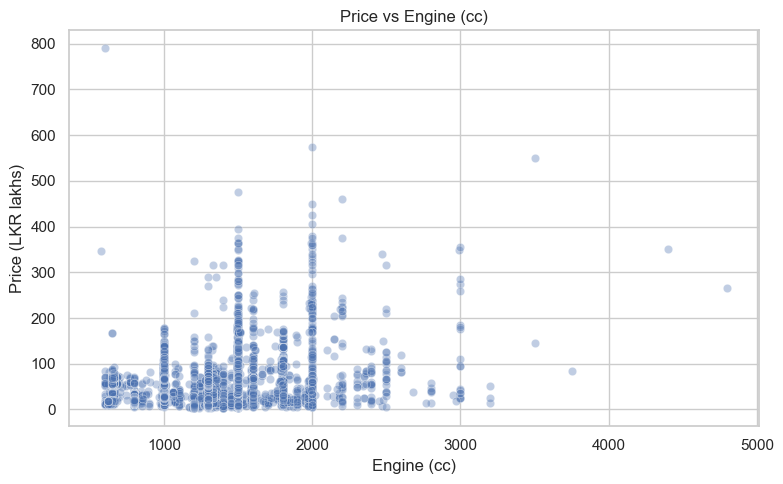

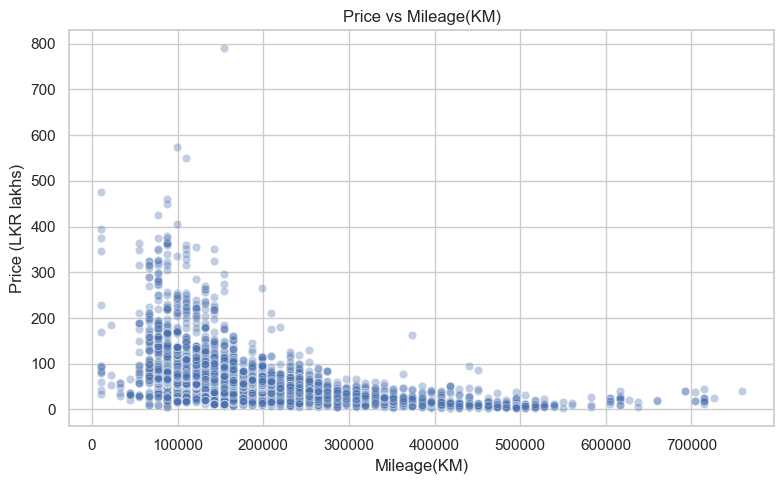

In [35]:
#Price vs. numeric variables 

#Examine relationship between price and each selected numerical variable
for x in[
    "YOM",
    "Engine (cc)",
    "Mileage(KM)"
]:
    #Select current variable and Price, removing rows with missing values
    temp=df[
        [x,"Price"]
    ].dropna()

    #Create a figure and axis for scatter plot 
    fig,ax=plt.subplots(
        figsize=(8,5)
    )

    #Plot relationsjip between numerical variable and vehicle price
    sns.scatterplot(
        data=temp,
        x=x,
        y="Price",
        alpha=0.35,
        ax=ax
    )

    #Add a descriptive title to scatter plot
    ax.set_title(
        f"Price vs {x}"
    )

    #Label y-axis with price unit
    ax.set_ylabel(
        "Price (LKR lakhs)"
    )

    #Adjust layout 
    fig.tight_layout()

    #Generate a filename based on variable name 
    filename=(
        "05_price_vs_"
        +x.replace(" ","_")
        .replace(")","")
        +".png"
    )

    #Save the scatter plot 
    fig.savefig(
        FIG_DIR/filename,
        dpi=200,
        bbox_inches="tight"
    )

    #Display plot
    plt.show()

In [36]:
#Categorical EDA

#Define categorical variables to examine during exploratory analysis 
categorical_columns=[
    "Brand",
    "Gear",
    "Fuel Type",
    "Town",
    "Leasing",
    "Condition",
    "AIR CONDITION",
    "POWER STEERING",
    "POWER MIRROR",
    "POWER WINDOW"
]

#Display most comon categories for each categorical variable 
for column in categorical_columns:
    #Print name of current categorical variable
    print(f"\n----{column}----")

    #Calculate category frequencies, including missing values
    display(
        df[column]
        .value_counts(dropna=False)
        .head(15)
        .rename("count")
        .to_frame()
    )


----Brand----


,count
Brand,
TOYOTA,3089
SUZUKI,2473
NISSAN,1248
HONDA,681
MITSUBISHI,284
PERODUA,257
MICRO,244
HYUNDAI,189
MAZDA,181



----Gear----


,count
Gear,
Automatic,6304
Manual,3484



----Fuel Type----


...

,count
POWER STEERING,
Available,8917
Not_Available,871



----POWER MIRROR----


,count
POWER MIRROR,
Available,7281
Not_Available,2507



----POWER WINDOW----


,count
POWER WINDOW,
Available,8002
Not_Available,1786


In [37]:
#Price by Gear

#Calculate number of listings and price staticts for each gear type 
stats = (
    df.groupby("Gear")["Price"]
      .agg(
          count="count",
          mean="mean",
          median="median"
      )
      .sort_values(
          "count",
          ascending=False
      )
)

# Display the price statistics by gear type
display(
    stats.round(2)
)

,count,mean,median
Gear,,,
Automatic,6285,69.62,61.50
Manual,3480,24.14,22.95


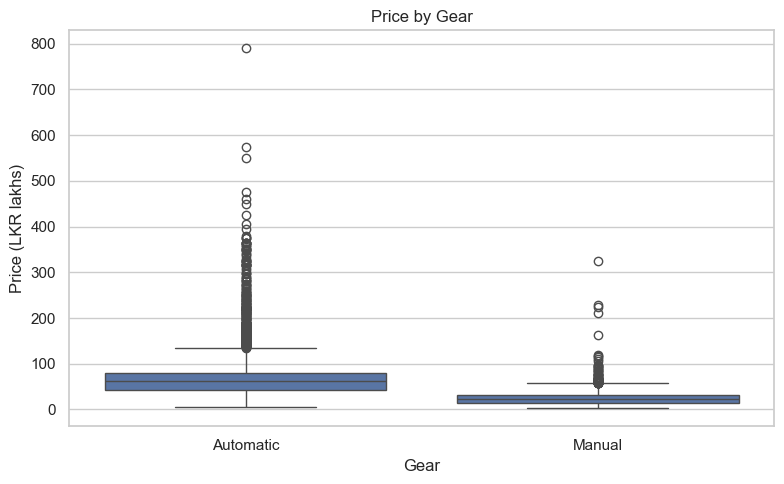

In [38]:
#Plot Price by Gear

#Create figure and axis for comparing prices across gear types
fig, ax = plt.subplots(
    figsize=(8, 5)
)


# Visualize the price distribution for each gear type
sns.boxplot(
    data=df,
    x="Gear",
    y="Price",
    ax=ax
)

ax.set_title(
    "Price by Gear"
)

ax.set_ylabel(
    "Price (LKR lakhs)"
)

# Adjust the layout
fig.tight_layout()

# Save the gear price comparison plot
fig.savefig(
    FIG_DIR / "06_price_by_gear.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot
plt.show()

In [39]:
#Price by Fuel Type

# Calculate the number of listings and price statistics for each fuel type
stats=(
    df.groupby("Fuel Type")["Price"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

# Display the price statistics by fuel type
display(
    stats.round(2)
)

,count,mean,median
Fuel Type,,,
Petrol,7846,49.57,38.50
Hybrid,1236,82.67,73.80
Diesel,614,40.56,24.75
Electric,69,81.43,54.41


In [42]:
# Vehicle features 

#Define the binary vehicle features to analyze
feature_columns = [
    "AIR CONDITION",
    "POWER STEERING",
    "POWER MIRROR",
    "POWER WINDOW"
]

#Analyze Vehicle features 

#Store price statistics for each level of every vehicle feature
results = []

# Analyze each vehicle feature separately
for column in feature_columns:

    # Group vehicles according to the current feature level
    for level, group in df.groupby(column):

        # Store the count, median price, and mean price for the feature level
        results.append({
            "feature": column,
            "level": level,
            "count": group["Price"].count(),
            "median_price": group["Price"].median(),
            "mean_price": group["Price"].mean()
        })

# Convert the collected results into a DataFrame
feature_summary = pd.DataFrame(results)

# Display the feature-level price summary
display(
    feature_summary.round(2)
)

# Save the vehicle feature price summary for future analysis and reporting
feature_summary.to_csv(
    TABLE_DIR / "feature_price_summary.csv",
    index=False
)

,feature,level,count,median_price,mean_price
0,AIR CONDITION,Available,9569,43.75,54.11
1,AIR CONDITION,Not_Available,196,13.10,19.47
2,POWER STEERING,Available,8895,48.75,56.69
3,POWER STEERING,Not_Available,870,15.50,19.88
4,POWER MIRROR,Available,7260,56.00,63.17
5,POWER MIRROR,Not_Available,2505,22.00,25.13
6,POWER WINDOW,Available,7981,53.80,60.41
7,POWER WINDOW,Not_Available,1784,17.50,22.10


In [45]:
#Model analysis

## Count how frequently each vehicle model appears in the dataset
model_counts=df["Model"].value_counts()

#Display total number of distinct vehicle models 
print(
    "Distinct models:",
    model_counts.size
)

# Count models that occur only once
print(
    "Singleton models:",
    (model_counts == 1).sum()
)

# Count models appearing at least five times
print(
    "Models appearing >= 5 times:",
    (model_counts >= 5).sum()
)

# Count models appearing at least ten times
print(
    "Models appearing >= 10 times:",
    (model_counts >= 10).sum()
)


Distinct models: 1554
Singleton models: 914
Models appearing >= 5 times: 296
Models appearing >= 10 times: 177


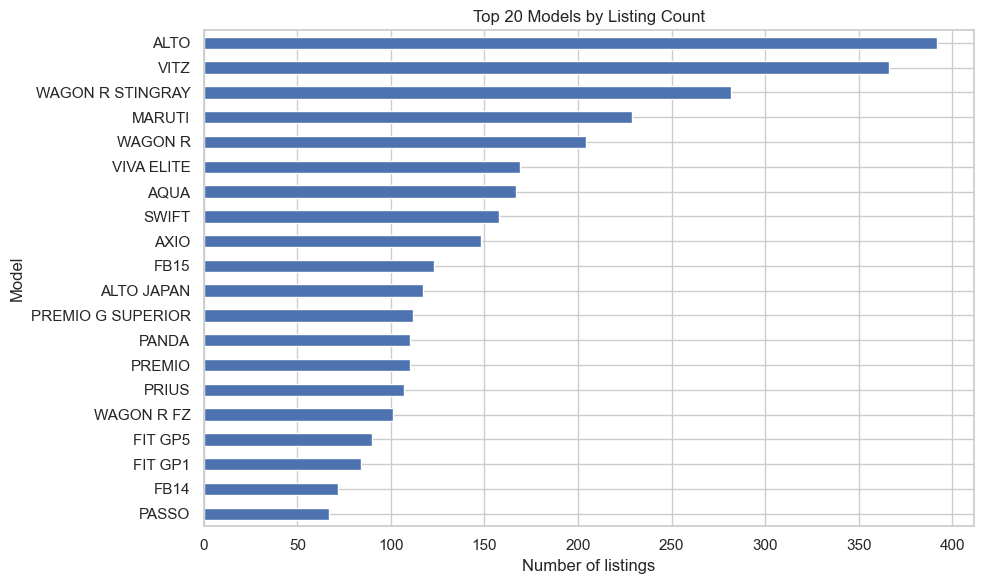

In [47]:
#Plot the most common models
# Create a figure and axis for the most frequently listed models
fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Plot the top 20 models by listing count as a horizontal bar chart
model_counts.head(20).sort_values().plot(
    kind="barh",
    ax=ax
)

# Add a descriptive title to the plot
ax.set_title(
    "Top 20 Models by Listing Count"
)

# Label the x-axis with the number of listings
ax.set_xlabel(
    "Number of listings"
)

# Adjust the layout for better presentation
fig.tight_layout()

# Save the model frequency plot
fig.savefig(
    FIG_DIR / "08_top_models_by_count.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot
plt.show()

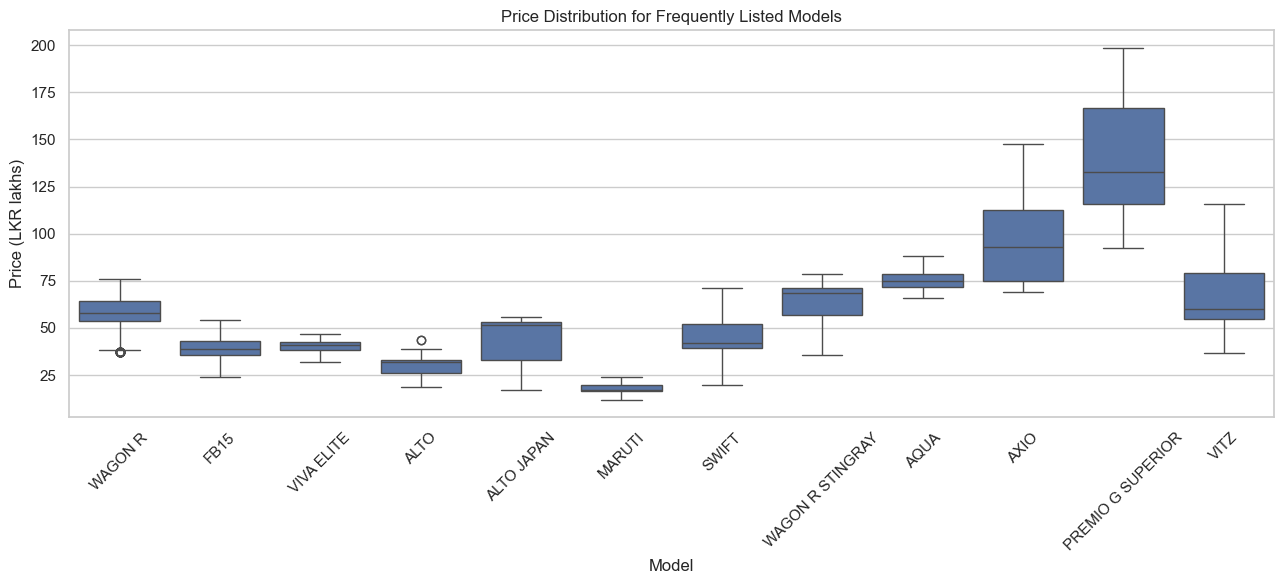

In [48]:
#Price by popular models 
# Select the 12 most frequently listed vehicle models
top_models = model_counts.head(12).index

# Filter the dataset to include only the selected popular models
temp = df[
    df["Model"].isin(top_models)
]

# Create a figure and axis for comparing popular models
fig, ax = plt.subplots(
    figsize=(13, 6)
)

# Visualize the price distribution for the selected popular models
sns.boxplot(
    data=temp,
    x="Model",
    y="Price",
    ax=ax
)

# Add a descriptive title to the plot
ax.set_title(
    "Price Distribution for Frequently Listed Models"
)

# Label the y-axis with the price unit
ax.set_ylabel(
    "Price (LKR lakhs)"
)

# Rotate model names to improve readability
ax.tick_params(
    axis="x",
    rotation=45
)

# Adjust the layout for better presentation
fig.tight_layout()

# Save the popular model price comparison plot
fig.savefig(
    FIG_DIR / "09_price_by_top_models.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot.
plt.show()

In [49]:
#Town Analysis 
# Count the number of vehicle listings for each town
town_counts = df["Town"].value_counts()

# Display the total number of distinct towns
print(
    "Distinct towns:",
    town_counts.size
)

# Count towns that occur only once
print(
    "Singleton towns:",
    (town_counts == 1).sum()
)

# Display the 20 towns with the highest number of listings
display(
    town_counts.head(20)
)

Distinct towns: 107
Singleton towns: 3


Town
Colombo                   1038
Gampaha                    655
Kurunegala                 646
Kandy                      638
Matara                     320
Malabe                     273
Galle                      253
Kadawatha                  235
Negombo                    228
Anuradapura                212
Homagama                   212
Dehiwala-Mount-Lavinia     189
Kegalle                    186
Panadura                   183
Kalutara                   169
Kuliyapitiya               161
Nugegoda                   160
Piliyandala                156
Horana                     149
Ratnapura                  147
Name: count, dtype: int64

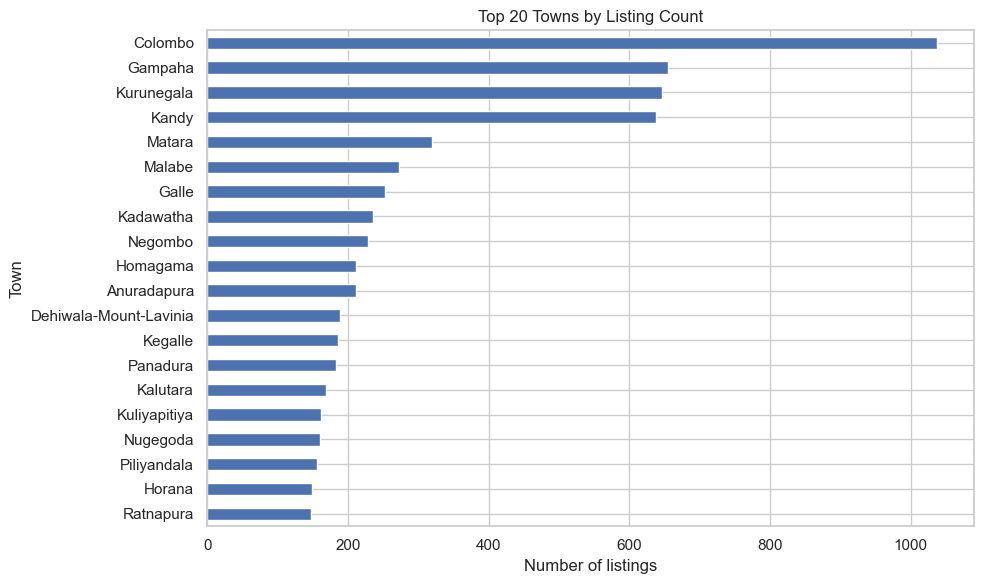

In [50]:
#Plot Town Analysis 

# Create a figure and axis for the town frequency plot
fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Plot the top 20 towns as a horizontal bar chart
town_counts.head(20).sort_values().plot(
    kind="barh",
    ax=ax
)

# Add a descriptive title to the plot
ax.set_title(
    "Top 20 Towns by Listing Count"
)

# Label the x-axis with the number of listings
ax.set_xlabel(
    "Number of listings"
)

# Adjust the layout for better presentation
fig.tight_layout()

# Save the town frequency plot
fig.savefig(
    FIG_DIR / "10_top_towns_by_count.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot
plt.show()


In [51]:
#Missing value visualization

# Calculate the number of missing values in each column
missing = (
    df.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
)

# Calculate the percentage of missing values in each column
missing["missing_pct"] = (
    missing["missing_count"]
    / len(df)
    * 100
).round(3)

# Keep only columns that contain missing values
missing = missing[
    missing["missing_count"] > 0
]

# Display the missing-value summary
display(missing)

,missing_count,missing_pct
YOM,12,0.123
Engine (cc),9,0.092
Mileage(KM),9,0.092
Price,23,0.235


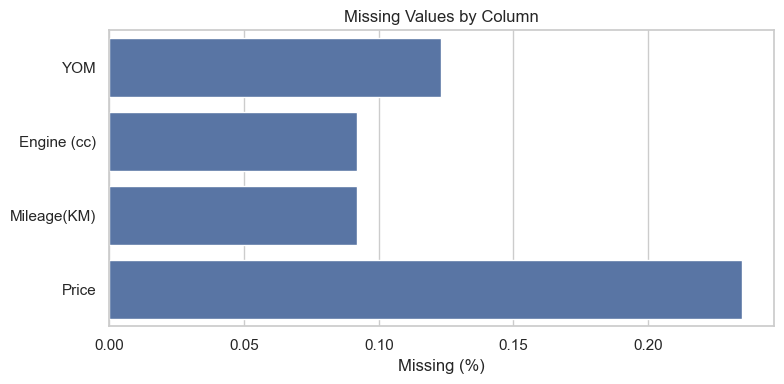

In [52]:
# Plot Missing value visualization

# Create a figure and axis for the missing value visualization
fig, ax = plt.subplots(
    figsize=(8, 4)
)

# Plot the percentage of missing values for each affected column
sns.barplot(
    x=missing["missing_pct"],
    y=missing.index,
    ax=ax
)

# Add a descriptive title to the plot
ax.set_title(
    "Missing Values by Column"
)

# Label the x-axis with the missing percentage
ax.set_xlabel(
    "Missing (%)"
)

# Remove the y-axis label because column names are already displayed
ax.set_ylabel("")

# Adjust the layout for better presentation
fig.tight_layout()

# Save the missing-value plot
fig.savefig(
    FIG_DIR / "11_missing_values.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot
plt.show()


In [54]:
#Outlier Analysis 

# Store the IQR-based outlier statistics for each numerical variable
outlier_results = []

# Apply the IQR method to the selected numerical variables
for column in [
    "YOM",
    "Engine (cc)",
    "Mileage(KM)",
    "Price"
]:

    # Remove missing values before calculating quartiles
    series = df[column].dropna()

    # Calculate the first quartile
    q1 = series.quantile(0.25)

    # Calculate the third quartile
    q3 = series.quantile(0.75)

    # Calculate the interquartile range
    iqr = q3 - q1

    # Calculate the lower IQR boundary
    lower = q1 - 1.5 * iqr

    # Calculate the upper IQR boundary
    upper = q3 + 1.5 * iqr

    # Identify observations outside the IQR boundaries
    mask = (
        (df[column] < lower) |
        (df[column] > upper)
    )

    # Store the calculated outlier statistics
    outlier_results.append({
        "column": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_pct": round(
            mask.mean() * 100,
            2
        )
    })

# Convert the outlier results into a DataFrame
outlier_summary = pd.DataFrame(
    outlier_results
)

# Display the IQR-based outlier summary
display(
    outlier_summary.round(2)
)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,YOM,2001.00,2015.00,14.00,1980.00,2036.00,76,0.78
1,Engine (cc),1000.00,1500.00,500.00,250.00,2250.00,110,1.12
2,Mileage(KM),110000.00,264000.00,154000.00,-121000.00,495000.00,76,0.78
3,Price,26.25,69.56,43.31,-38.72,134.53,389,3.97


In [56]:
#Investigate expensive vehicles

# Define the vehicle attributes to inspect for the highest-priced listings
columns = [
    "Brand",
    "Model",
    "YOM",
    "Engine (cc)",
    "Gear",
    "Fuel Type",
    "Mileage(KM)",
    "Town",
    "Price"
]

# Display the 20 highest-priced vehicles for manual investigation
display(
    df.nlargest(
        20,
        "Price"
    )[columns]
)

,Brand,Model,YOM,Engine (cc),Gear,Fuel Type,Mileage(KM),Town,Price
8417,TOYOTA,LEXUS 600HL,2011.0,600.0,Automatic,Hybrid,154000.0,Katunayake,790.0
138,BMW,740LE M SPORT,2016.0,2000.0,Automatic,Petrol,99000.0,Matale,575.0
1776,MERCEDES-BENZ,S400 LONG WHEEL BASE,2015.0,3500.0,Automatic,Petrol,110000.0,Colombo,550.0
55,AUDI,Q4,2024.0,1500.0,Automatic,Electric,11000.0,Gampola,475.0
133,BMW,530I M SPORT,2017.0,2200.0,Automatic,Petrol,88000.0,Colombo,460.0
109,BMW,430I GRAN COUPE,2017.0,2000.0,Automatic,Petrol,88000.0,Dehiwala-Mount-Lavinia,450.0
153,BMW,M SPORT,2018.0,2000.0,Automatic,Petrol,77000.0,Moratuwa,425.0
1733,MERCEDES-BENZ,E200,2016.0,2000.0,Automatic,Petrol,99000.0,Colombo,405.0
159,BYD,SEAL,2024.0,1500.0,Automatic,Electric,11000.0,Dehiwala-Mount-Lavinia,394.5
148,BMW,G30 530I,2017.0,2000.0,Automatic,Petrol,88000.0,Colombo,380.0


In [57]:
#Listing date analysis

# Aggregate listing counts and price statistics for each listing date
daily = (
    df.groupby("Date_parsed")
      .agg(
          listings=("Price", "count"),
          median_price=("Price", "median"),
          mean_price=("Price", "mean")
      )
      .reset_index()
      .sort_values("Date_parsed")
)

# Display the earliest daily observations
display(daily.head())

# Display the latest daily observations
display(daily.tail())


,Date_parsed,listings,median_price,mean_price
0,2024-12-03,1,58.000,58.000000
1,2024-12-04,124,46.500,54.844965
2,2024-12-05,109,52.500,54.512522
3,2024-12-06,78,39.075,43.640037
4,2024-12-07,98,40.000,52.937254


,Date_parsed,listings,median_price,mean_price
60,2025-02-01,405,42.500000,52.765955
61,2025-02-02,391,53.250000,56.895054
62,2025-02-03,456,45.000000,55.118507
63,2025-02-04,532,39.850000,52.046606
64,2025-02-05,642,42.592857,53.448982


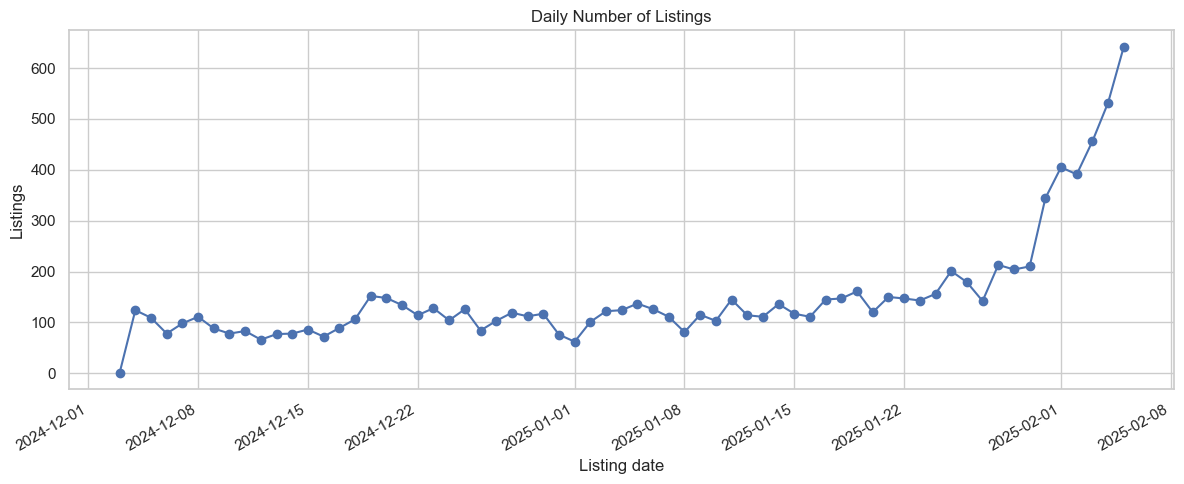

In [ ]:
#Listing counts 

# Create a figure and axis for the daily listing count trend
fig, ax = plt.subplots(
    figsize=(12, 5)
)

# Plot the number of listings recorded on each date
ax.plot(
    daily["Date_parsed"],
    daily["listings"],
    marker="o"
)

# Add a descriptive title to the plot
ax.set_title(
    "Daily Number of Listings"
)

# Label the x-axis with the listing date
ax.set_xlabel(
    "Listing date"
)

# Label the y-axis with the number of listings
ax.set_ylabel(
    "Listings"
)

# Automatically format the date labels for readability
fig.autofmt_xdate()

# Adjust the layout for better presentation
fig.tight_layout()

# Save the daily listing count plot
fig.savefig(
    FIG_DIR / "12_daily_listing_counts.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot
plt.show()

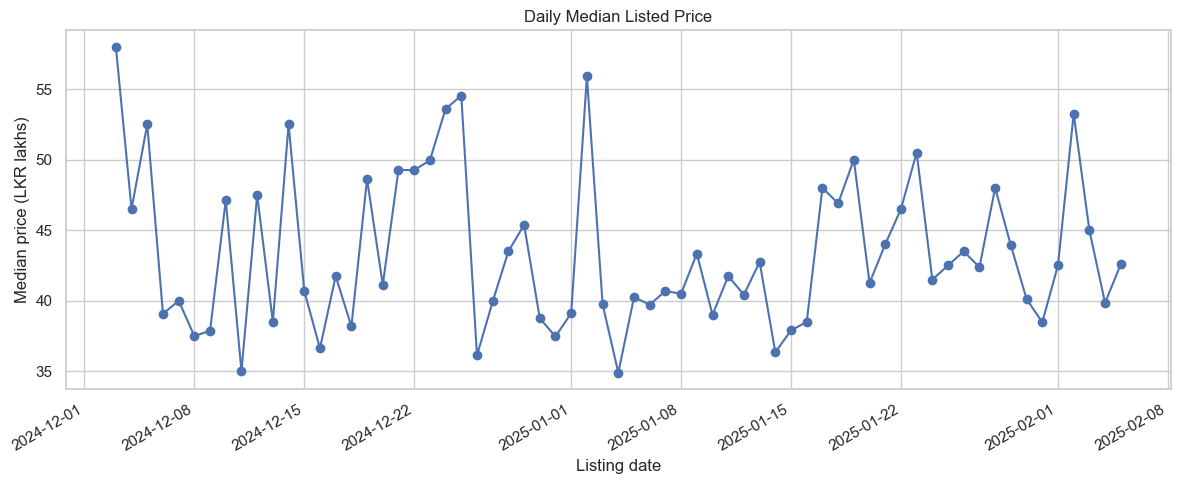

In [59]:
#Median price 

# Create a figure and axis for the daily median price trend
fig, ax = plt.subplots(
    figsize=(12, 5)
)

# Plot the median listed price for each date
ax.plot(
    daily["Date_parsed"],
    daily["median_price"],
    marker="o"
)

# Add a descriptive title to the plot
ax.set_title(
    "Daily Median Listed Price"
)

# Label the x-axis with the listing date
ax.set_xlabel(
    "Listing date"
)

# Label the y-axis with the median price
ax.set_ylabel(
    "Median price (LKR lakhs)"
)

# Automatically format the date labels for readability
fig.autofmt_xdate()

# Adjust the layout
fig.tight_layout()

# Save the daily median price plot
fig.savefig(
    FIG_DIR / "13_daily_median_price.png",
    dpi=200,
    bbox_inches="tight"
)

# Display the plot
plt.show()